                    Avg_Recency_Days  Avg_Frequency  Avg_Monetary_USD  \
Customer_Segment                                                        
Champions                        7.7           12.9            7184.3   
Loyal Customers                 25.3            4.8            2265.2   
Need Attention                  82.8            4.6            2021.4   
At Risk                        214.7            3.2            1972.0   
About to Sleep                  85.1            1.6             493.9   
Promising / Recent              25.5            1.4             322.2   
Lost                           255.6            1.2             299.0   

                    Customer_Count  Pct_Customers  
Customer_Segment                                   
Champions                      664           15.3  
Loyal Customers                948           21.9  
Need Attention                 376            8.7  
At Risk                        229            5.3  
About to Sleep                

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12820\4004676545.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


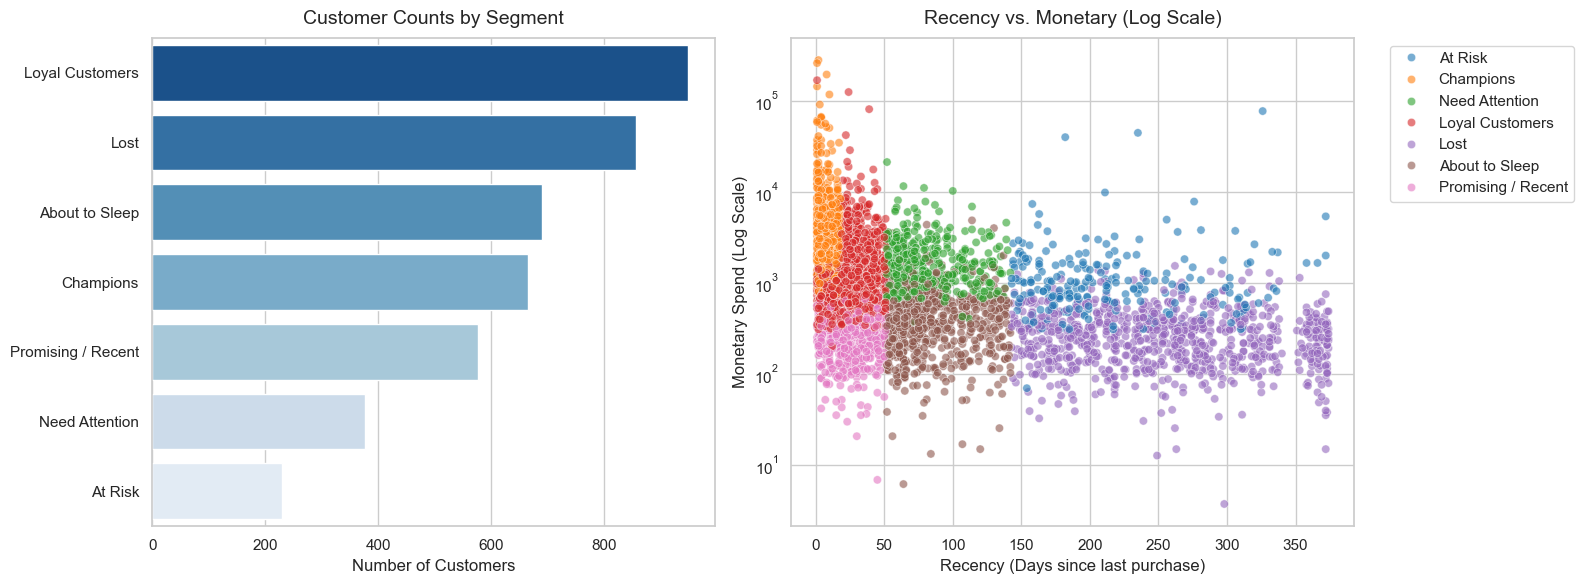

In [12]:
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. Load and Clean Data
# ==========================================
# Using the standard UCI Online Retail format
df = pd.read_csv("data.csv", encoding="ISO-8859-1")

# Clean missing Customer IDs and strip descriptions
df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype(int).astype(str)

# Remove cancellations (invoices starting with 'C') and invalid quantities/prices
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Parse timestamps and compute total spend per line item
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["TotalSpend"] = df["Quantity"] * df["UnitPrice"]

# ==========================================
# 2. Calculate RFM Metrics
# ==========================================
# Set snapshot date as 1 day after the latest transaction in the dataset
snapshot_date = df["InvoiceDate"].max() + dt.timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda date: (snapshot_date - date.max()).days,  # Recency
    "InvoiceNo": "nunique",                                         # Frequency
    "TotalSpend": "sum"                                             # Monetary
}).reset_index()

rfm.rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "TotalSpend": "Monetary"
}, inplace=True)

# ==========================================
# 3. RFM Scoring (Quantiles 1 to 4)
# ==========================================
# Lower Recency is better (rank 4), Higher Frequency & Monetary are better (rank 4)
rfm["R_Score"] = pd.qcut(rfm["Recency"], q=4, labels=[4, 3, 2, 1])

# Frequency often has duplicate values at lower counts; drop duplicates handles ties
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=4, labels=[1, 2, 3, 4])
rfm["M_Score"] = pd.qcut(rfm["Monetary"], q=4, labels=[1, 2, 3, 4])

# Combine into a composite RFM segment code
rfm["RFM_Segment"] = (
    rfm["R_Score"].astype(str) + 
    rfm["F_Score"].astype(str) + 
    rfm["M_Score"].astype(str)
)
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int) + 
    rfm["F_Score"].astype(int) + 
    rfm["M_Score"].astype(int)
)

# ==========================================
# 4. Map Customer Segments
# ==========================================
def assign_segment(df_row):
    r = int(df_row["R_Score"])
    fm = (int(df_row["F_Score"]) + int(df_row["M_Score"])) / 2

    if r >= 4 and fm >= 3.5:
        return "Champions"
    elif r >= 3 and fm >= 2.5:
        return "Loyal Customers"
    elif r >= 3 and fm < 2.5:
        return "Promising / Recent"
    elif r == 2 and fm >= 3:
        return "Need Attention"
    elif r == 2 and fm < 3:
        return "About to Sleep"
    elif r == 1 and fm >= 2.5:
        return "At Risk"
    else:
        return "Lost"

rfm["Customer_Segment"] = rfm.apply(assign_segment, axis=1)

# Summary table per segment
segment_summary = rfm.groupby("Customer_Segment").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": ["mean", "count"]
}).round(1)
segment_summary.columns = ["Avg_Recency_Days", "Avg_Frequency", "Avg_Monetary_USD", "Customer_Count"]
segment_summary["Pct_Customers"] = (
    (segment_summary["Customer_Count"] / len(rfm)) * 100
).round(1)
print(segment_summary.sort_values(by="Avg_Monetary_USD", ascending=False))

# ==========================================
# 5. Visual EDA for Portfolio
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Customer distribution across segments
order = segment_summary.sort_values(by="Customer_Count", ascending=False).index
sns.countplot(
    data=rfm, 
    y="Customer_Segment", 
    order=order, 
    palette="Blues_r", 
    ax=axes[0]
)
axes[0].set_title("Customer Counts by Segment", fontsize=14, pad=10)
axes[0].set_xlabel("Number of Customers")
axes[0].set_ylabel("")

# Subplot 2: Recency vs Monetary scatter (log scale due to spend skew)
sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Customer_Segment",
    palette="tab10",
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_yscale("log")
axes[1].set_title("Recency vs. Monetary (Log Scale)", fontsize=14, pad=10)
axes[1].set_xlabel("Recency (Days since last purchase)")
axes[1].set_ylabel("Monetary Spend (Log Scale)")
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

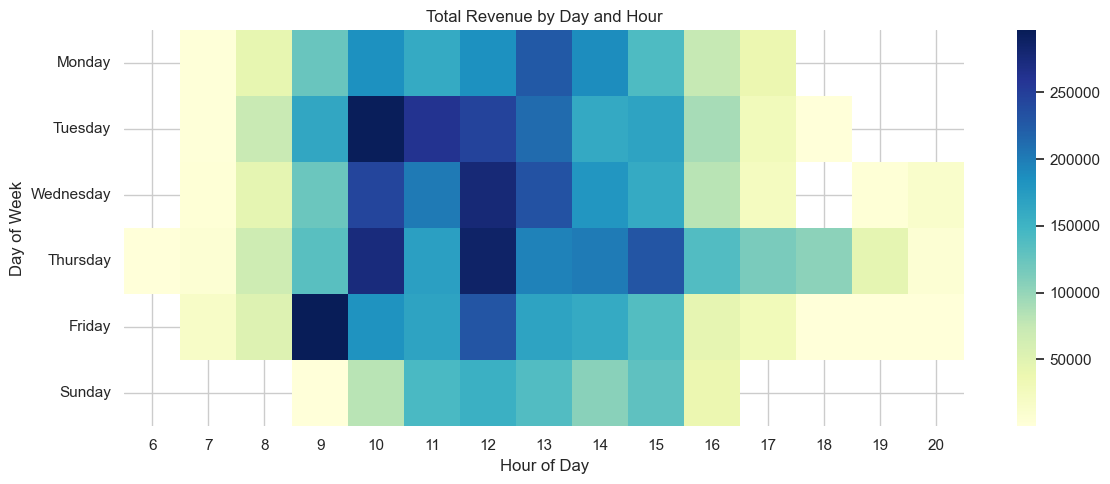

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv('data.csv', encoding='ISO-8859-1')

# 2. Basic Cleaning
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

# 3. Visualization: Sales Activity Heatmap
sales_pivot = df.pivot_table(index='DayOfWeek', columns='Hour', values='TotalAmount', aggfunc='sum')
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
sales_pivot = sales_pivot.reindex(days_order)

plt.figure(figsize=(12, 5))
sns.heatmap(sales_pivot, cmap='YlGnBu', annot=False, fmt='.0f')
plt.title('Total Revenue by Day and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

In [13]:
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

# ==========================================
# 1. Load, Clean & Compute RFM Metrics
# ==========================================
df = pd.read_csv("data.csv", encoding="ISO-8859-1")
df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype(int).astype(str)
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["TotalSpend"] = df["Quantity"] * df["UnitPrice"]

snapshot_date = df["InvoiceDate"].max() + dt.timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda d: (snapshot_date - d.max()).days,
    "InvoiceNo": "nunique",
    "TotalSpend": "sum"
}).reset_index()

rfm.rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "TotalSpend": "Monetary"
}, inplace=True)

# ==========================================
# 2. Preprocessing for K-Means (Log + Scaling)
# ==========================================
# K-Means assumes spherical clusters and equal variance.
# RFM data is heavily right-skewed, requiring log-transformation.
rfm_features = ["Recency", "Frequency", "Monetary"]
rfm_log = np.log1p(rfm[rfm_features])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_features)

# ==========================================
# 3. Model Diagnostics: Elbow & Silhouette
# ==========================================
k_range = range(2, 9)
wcss = []              # Within-cluster sum of squares (Inertia)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

# Diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), wcss, marker="o", color="b")
axes[0].set_title("Elbow Method (Inertia vs. K)", fontsize=13)
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (WCSS)")

axes[1].plot(list(k_range), silhouette_scores, marker="s", color="darkorange")
axes[1].set_title("Silhouette Scores vs. K", fontsize=13)
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

# ==========================================
# 4. Final Fit & Cluster Assignment (k=4)
# ==========================================
optimal_k = 4
kmeans_model = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
rfm["Cluster"] = kmeans_model.fit_predict(rfm_scaled)

# ==========================================
# 5. Cluster Interpretation & Profiling
# ==========================================
cluster_profile = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "CustomerID": "count"
}).rename(columns={"CustomerID": "Count"}).round(1)

cluster_profile["Pct_Customers"] = (
    (cluster_profile["Count"] / len(rfm)) * 100
).round(1)

print("\n--- Cluster Summary Profiles ---")
print(cluster_profile.sort_values(by="Monetary", ascending=False))

# ==========================================
# 6. Cluster Visualization
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Recency vs Frequency
sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="Set2",
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_yscale("log")
axes[0].set_title("Recency vs Frequency (Log Scale)", fontsize=13)
axes[0].set_xlabel("Recency (Days)")
axes[0].set_ylabel("Frequency (Transactions)")

# Plot 2: Frequency vs Monetary
sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2",
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Frequency vs Monetary Spend (Log-Log Scale)", fontsize=13)
axes[1].set_xlabel("Frequency (Transactions)")
axes[1].set_ylabel("Monetary ($)")

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'online_retail.csv'